## Final Project - Part 1 of 3

# Model Selection

I have chosen Option A: Spring-Mass System:
(m)f''(t) + (c)f'(t) + (k)f(t) = 0

# Parameter Research

Due to my time in Longhorn Racing, I have chosen parameters that reflect the modeling of an FSAE car suspension. 

Mass: The mass of a cars suspension system like an FSAE vehicle is usually modeled per wheel (quarter car). Our car here at UT is roughly 452lb, or 205kg. 205kg/4wheels = 51.25kg.

Spring Constant: Ideal spring constants take into account the weight of the car, load balancing, and the events the car will be participating in. Here I am shooting for a spring constant that would allow for a comfortable a ride while maintaining optimal stiffness for high-speed and low curvature cornering and bumps in the road. For my spring selection I have utilized the mean spring constant for a lighter FSAE car:  150lb/in, or 26270N/m/

Damping Coefficient: From the equation C = 2(b)sqrt(m * k) where, the damping ratio, is usually a ratio such as 0.6, c = 1392Ns/m. I have gotten my b value from average FSAE car damping coefficients. This damping ration offers a balance between handling response, ride smoothness, and managin energy through bumps and corners. It also minimizes vibrations and maintains grip without enduxing load variation.

Initial Condition: We are going to start the car system on a speed bump of 10in or 0.254m. f(0) = .254, f'(0) = 0, f''(0) = 0. These initial conditions make sense because it is likely a car would start on a bump, uneven ground, or rough terrain. This initial condition also allows me to model a more dynamic path to equilibrium.

Sources:  https://www.f1-forecast.com/pdf/F1-Files/Design%20of%20a%20Formula%20Student%20Race%20Car%20Spring-Damper%20System.pdf

https://www.fsae.com/forums/archive/index.php/t-10472.html?s=5ce42bd67e1ff12ad0ef134603742939

https://www.hypercoils.com/shop/coilover-springs?refinementList%5BinsideDiameter_standard%5D%5B0%5D=1.45&page=1&configure%5Bfilters%5D=category%3A%22Coilover%20Springs%20Standard%22&configure%5BhitsPerPage%5D=1000&configure%5Bdistinct%5D=1

# Numerical Implementation

y1 = y, y2 = dy/dt, y1' = y2, y2' = -(c/m)y2 - (k/m)y1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 51.26
c = 1392
k = 26270

# Base Function
def df(t, x):
    x1, x2 = x
    dx1 = x2
    dx2 = -(c/m)*x2 - (k/m)*x1
    return np.array([dx1, dx2])

In [2]:
# Euler Forward Method
def euler_forward_method(h, t_start, t_end, y_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros((len(t_values), len(y_0)))
    
    # Set initial conditions
    y_values[0] = y_0
    
    for i in range(1, len(t_values)):
        # Update equations for Euler's Method
        y_values[i] = y_values[i-1] + h * df(t_values[i-1], y_values[i-1])
    
    return t_values, y_values

In [3]:
# Fourth-Order Runge-Kutta Method
def runge_kutta_method(h, t_start, t_end, y_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros((len(t_values), len(y_0)))
    
    # Set initial conditions
    y_values[0] = y_0
    
    for i in range(1, len(t_values)):
        t = t_values[i-1]
        y = y_values[i-1]
        # Runge-Kutta Slopes
        k1 = df(t, y)
        k2 = df((t + h/2),(y+k1*h/2))
        k3 = df((t + h/2),(y+k2*h/2))
        k4 = df((t + h),(y+k3*h))
        # Update equations for Runge-Kutta Method
        y_values[i] = y_values[i-1] + h*(k1+2*k2+2*k3+k4)/6
        
        return t_values, y_values
    

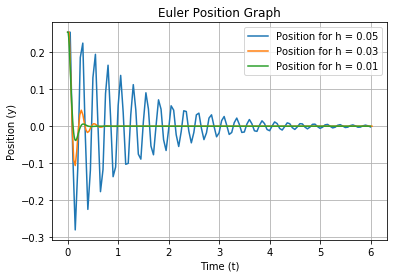

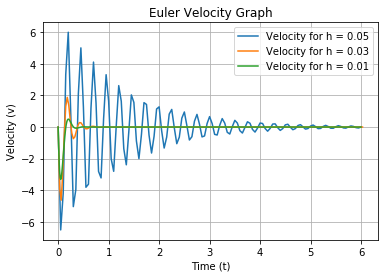

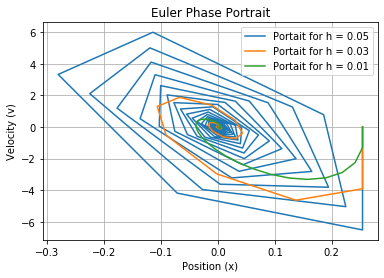

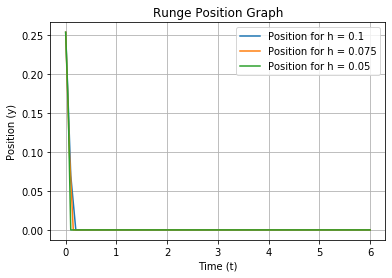

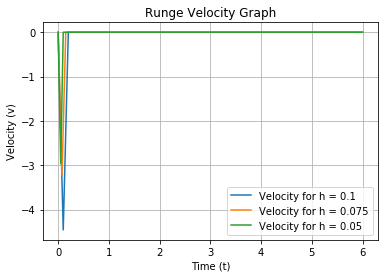

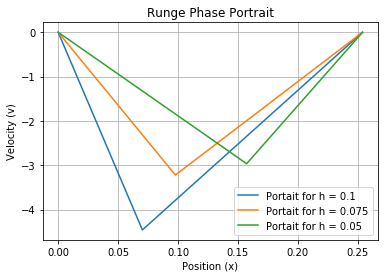

In [4]:
# Test Case
eulerhs = [0.05, 0.03, 0.01]
rungehs = [0.1, 0.075 , 0.05] #The h values have been adjusted due to the Runge method not requiring such small h values.
t_start = 0
t_end = 6
y_0 = np.array([.254,0])

# Euler
plt.figure()
for h in eulerhs:
    t, Y = euler_forward_method(h, t_start, t_end, y_0)
    pos = Y[:,0]
    plt.plot(t, pos, label='Position for h = ' + str(h))

plt.title("Euler Position Graph")
plt.xlabel("Time (t)")
plt.ylabel("Position (y)")
plt.grid()
plt.legend()
plt.show()

plt.figure()
for h in eulerhs:
    t, Y = euler_forward_method(h, t_start, t_end, y_0)
    vel = Y[:,1]
    plt.plot(t, vel, label='Velocity for h = ' + str(h))

plt.title("Euler Velocity Graph")
plt.xlabel("Time (t)")
plt.ylabel("Velocity (v)")
plt.grid()
plt.legend()
plt.show()

plt.figure()
for h in eulerhs:
    t, Y = euler_forward_method(h, t_start, t_end, y_0)
    # Phase Portrait
    plt.plot(Y[:,0], Y[:,1], label="Portait for h = " + str(h))

plt.title("Euler Phase Portrait")
plt.xlabel("Position (x)")
plt.ylabel("Velocity (v)")
plt.grid()
plt.legend()
plt.show()

# Runge-Kutta
plt.figure()
for h in rungehs:
    t, Y = runge_kutta_method(h, t_start, t_end, y_0)
    pos = Y[:,0]
    plt.plot(t, pos, label='Position for h = ' + str(h))

plt.title("Runge Position Graph")
plt.xlabel("Time (t)")
plt.ylabel("Position (y)")
plt.grid()
plt.legend()
plt.show()

plt.figure()
for h in rungehs:
    t, Y = runge_kutta_method(h, t_start, t_end, y_0)
    vel = Y[:,1]
    plt.plot(t, vel, label='Velocity for h = ' + str(h))

plt.title("Runge Velocity Graph")
plt.xlabel("Time (t)")
plt.ylabel("Velocity (v)")
plt.grid()
plt.legend()
plt.show()

plt.figure()
for h in rungehs:
    t, Y = runge_kutta_method(h, t_start, t_end, y_0)
    # Phase Portrait
    plt.plot(Y[:,0], Y[:,1], label="Portait for h = " + str(h))

plt.title("Runge Phase Portrait")
plt.xlabel("Position (x)")
plt.ylabel("Velocity (v)")
plt.grid()
plt.legend()
plt.show()

Overall, the Runge-Kutta method produces a smoother and more accurate solution as detaled by the largely sinusoidal approach to steady-state equilibrium. The Euler method is largely sinusoidal which is not entirely accurate to what would be happening physically. This is also why it produces such large numerical error and produces a helical phase portrait. At larger h values, the Euler method damps too quickly or not enough, which results in instability and the solution blowing up. Euler's method however is computationally cheaper (O(h) accuracy) versus Runge-Kutta's 4th order accuracy (O(h^4) accuracy). Due to this Euler is much more sensitive to step size and cannot except as large step sizes that Runge-Kutta could. 

# Stability Analysis

In [5]:
# Maximum Euler h Analysis, where max(h) = 2/abs(lambda)
A = np.array([[0,1],[-(k/m),-(c/m)]])
eigvals = np.linalg.eigvals(A)
maxh = 2/max(np.abs(eigvals))
print("The maximum euler h value is " + str(maxh))

# Maximum Runge-Kutta h Analysis, where max(h) = 2.8/abs(lambda)
maxh = 2.8/max(np.abs(eigvals))
print("The maximum Runge-Kutta h value is " + str(maxh))

The maximum euler h value is 0.08834648196461142
The maximum Runge-Kutta h value is 0.123685074750456


In [6]:
# Analytical Solution
b = 0.6
wn = np.sqrt(k/m)
wd = wn*np.sqrt(1-(b*b))
# From initial conditions f(0) = .254 and f'(0) = 0 I can algebraically solve for c1 and c2
c1 = 0.254
c2 = b*wn*c1/wd
def f(t):
    return np.exp(-b*wn*t)*(c1*np.cos(wd*t)+c2*np.sin(wd*t))

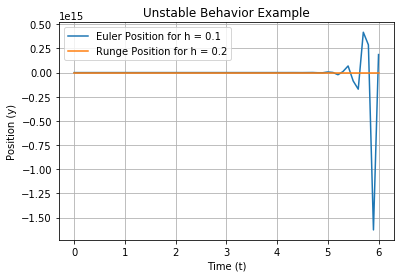

In [7]:
# Too Large Step Size
h = 0.1
t, Y = euler_forward_method(h, t_start, t_end, y_0)
pos = Y[:,0]
plt.plot(t, pos, label='Euler Position for h = ' + str(h))

h = 0.2
t, Y = runge_kutta_method(h, t_start, t_end, y_0)
pos = Y[:,0]
plt.plot(t, pos, label='Runge Position for h = ' + str(h))

plt.title("Unstable Behavior Example")
plt.xlabel("Time (t)")
plt.ylabel("Position (y)")
plt.grid()
plt.legend()
plt.show()

#In this case, the Runge-Kutta method is unable to accurately model the exponential decay and the euler method blows up.

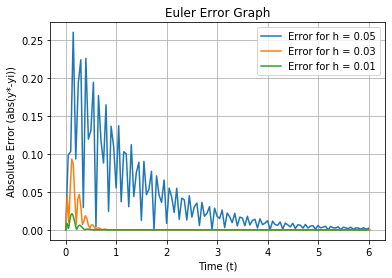

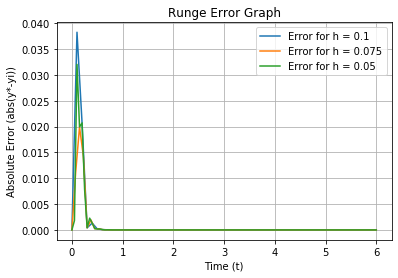

In [8]:
# Error Analysis
max_euler_error = []
max_runge_error = []

plt.figure()
for h in eulerhs:
    et, Y = euler_forward_method(h, t_start, t_end, y_0)
    pos = Y[:,0]
    euler_error = np.abs(pos - f(et))
    max_euler_error.append(max(euler_error))
    plt.plot(et, euler_error, label='Error for h = ' + str(h))
    
plt.title("Euler Error Graph")
plt.xlabel("Time (t)")
plt.ylabel("Absolute Error (abs(y*-yi))")
plt.grid()
plt.legend()
plt.show()

for h in rungehs:
    rt, Y = runge_kutta_method(h, t_start, t_end, y_0)
    pos = Y[:,0]
    runge_error = np.abs(pos - f(rt))
    max_runge_error.append(max(runge_error))
    plt.plot(rt, runge_error, label='Error for h = ' + str(h))
    
plt.title("Runge Error Graph")
plt.xlabel("Time (t)")
plt.ylabel("Absolute Error (abs(y*-yi))")
plt.grid()
plt.legend()
plt.show()


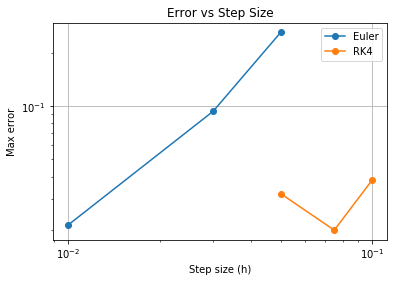

In [9]:
plt.figure()
plt.loglog(eulerhs, max_euler_error, 'o-', label='Euler')
plt.loglog(rungehs, max_runge_error, 'o-', label='RK4')
plt.xlabel("Step size (h)")
plt.ylabel("Max error")
plt.title("Error vs Step Size")
plt.legend()
plt.grid()
plt.show()

This case study shows that numerical instabilities do in fact lead to non-physical results. This is due to resolution of an approximation method not accurately capturing changes in y with regard to x which then render non-physical results, such as the position of a spring-mass system approaching infinity when realistically it would sinusoidally approach zero. The solution would grow unboundedly instead of approaching a steady state equilibrium, as is characteristic of damped systems. Therefor we can conclude that a more stable and accurately resoluted system will act more in line with the expected physical behavior. 

In [10]:
euler_slope = np.polyfit(np.log(eulerhs), np.log(max_euler_error), 1)[0]
runge_slope = np.polyfit(np.log(rungehs), np.log(max_runge_error), 1)[0]

print("Euler slope:", euler_slope)
print("Runge slope:", runge_slope)

Euler slope: 1.5238265816505494
Runge slope: 0.16244945968596983


# Conclusion

Overall, the Runge-Kutta method performed better for this system due to it;s ability accurately grpah the exponential decay of the spring-mass sytem and it's ability to use higher h values and reducing the memory stored when handling data arrays. Despite requiring more computational power and run-time, the difference in computational power was negligible enough in this application which allowed the Runge-Kutta to shine in it's accuracy. For smaller mathematical modelling applications and on small time scales, higher accuracy outweighs computational costs. I would recommend using Euler's Forward method on applications with larger time scales, due to its cheap computational costs. I also believe with more advanced data structures that the Runge-Kutta method could prove to be much more computationally efficient at larger time-scales. Through this project I have learned the trade off between accuracy, computational costs, and how time scale and forcing dynamics in a system drive decisions to prioritize accuracy or computational costs.